In [1]:
#### 1. Installing and importing libraries
# conda install conda-forge::scikit-learn
# conda install pandas
# conda install conda-forge::geopandas
# pip install pykrige (for the spatial interpolation), scikit-learn (NN and CV), numpy, and pandas
# pip install numpy pandas matplotlib scikit-learn pykrige statsmodels
# conda install -c anaconda statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pykrige.ok import OrdinaryKriging
# To ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 2. Loading the dataset
data = pd.read_csv('E:/VData/SData/Wells3.csv')

In [3]:
seed = 42

In [4]:
data.head()

,x_coord,y_coord,Depth,pH,SO4,NO3,T
0,17.23,15.57,201.00,6.00,825.0,24.0,27.0
1,17.48,15.83,220.00,6.00,925.0,5.0,27.0
2,16.83,14.17,38.88,6.22,13.0,7.0,28.8
3,16.95,14.43,35.90,6.39,11.0,6.0,25.0
4,16.48,13.25,53.00,6.40,2.5,1.2,30.7


In [5]:
# 3. data preparation

In [6]:
# Target: Wells pH 
y = data['NO3'].values

In [7]:
# The feature variables
X_features = data[['T', 'Depth']].values

In [8]:
# Spatial coordinates (X, Y)
X_coords = data[['x_coord', 'y_coord']].values

In [9]:
# Splitting the dataset into training and testing dataset
X_f_train, X_f_test, X_c_train, X_c_test, y_train, y_test = train_test_split(X_coords, X_features, y, test_size = 0.3, random_state = 42)


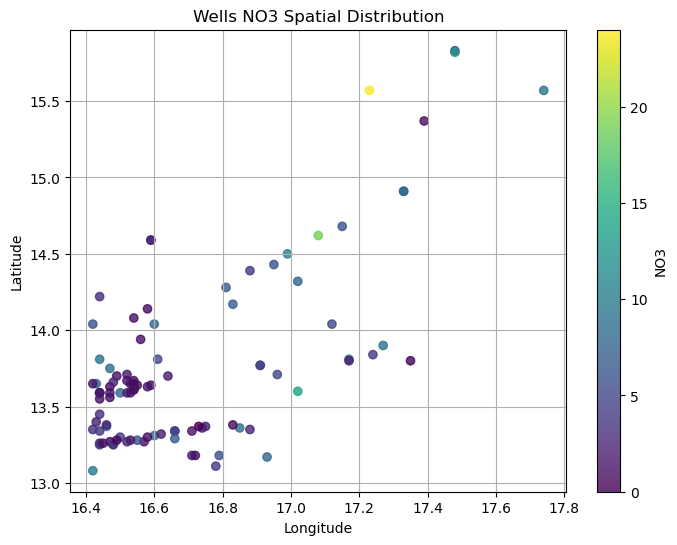

In [10]:
# 4. Data Exploration: Visualising spatial distribution of wells pH
plt.figure(figsize = (8, 6))
scatter = plt.scatter(data['x_coord'], data['y_coord'], c = data['NO3'], cmap ='viridis', alpha = 0.8)
plt.colorbar(scatter, label = 'NO3')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wells NO3 Spatial Distribution')
plt.grid(True)
plt.show()


In [55]:
#### 5. Training the Regression model and Calculating Residuals

In [11]:
# a. Initializing the Random Forest model
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

In [12]:
# b. Fitting the Random Forestmodel
rf.fit(X_f_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# Making Predictions 
y_pred_train = rf.predict(X_f_train) # Predicting on the training data
y_pred_test = rf.predict(X_f_test) # Predicting on the testing data

In [17]:
# b. Compute residuals (y_true - y_pred)
residuals_train = y_train - y_pred_train # Training residuals
#residuals_test = y_test - y_pred_test    # Testing residuals

In [59]:
##### 6. Performing Ordinary Kriging on Residuals

In [18]:
# a. Fit Ordinary Kriging on spatial coordinates and residuals
OK = OrdinaryKriging(
    x = X_c_train[:, 0],
    y = X_c_train[:, 1],
    z = residuals_train,
    variogram_model = 'gaussian', # Please run the krige CV to find your best parameters
    verbose = False,
    enable_plotting = False
)

In [19]:
# Predicting residual using test coordinates
kriged_residuals_test, _ = OK.execute('points', X_c_test[:, 0], X_c_test[:, 1])

In [20]:
# b. Final Prediction (RF Trend + Kriged Residuals)
y_pred_rfrk = y_pred_test + kriged_residuals_test

In [62]:
##### 7. Evaluate Model Performance: Compare standard Linear Regression against Regression Kriging:

In [21]:
# # a. Metrics for Pure RF Regression
r2_rf = r2_score(y_test, y_pred_test)
mse_rf = mean_squared_error(y_test, y_pred_test)

In [22]:
# b. Metrics for RF Kriging Regression
r2_rf_rk = r2_score(y_test, y_pred_rfrk)
mse_rf_rk = mean_squared_error(y_test, y_pred_rfrk)

In [24]:
# c. Comparison Table
comparison_table = pd.DataFrame({
    'Model': ['Random Forest', 'RF R. Kriging'],
    'R2 Score': [r2_rf, r2_rf_rk],
    'MSE': [mse_rf, mse_rf_rk]
})

In [25]:
print(comparison_table)

           Model  R2 Score        MSE
0  Random Forest  0.122791  23.935344
1  RF R. Kriging  0.126549  23.832797
